# 🎓 Modelo de Predicción de Deserción Escolar (Baja General)
**Versión:** High Sensitivity (Prioridad en Detección) | **Motor:** CatBoost (GPU Enabled)

---

### 📋 Descripción General
Este notebook ejecuta un flujo de trabajo completo de Machine Learning para predecir la probabilidad de que un alumno cause **Baja General**. El objetivo no es solo predecir, sino categorizar el riesgo en un **Semáforo de Acción (Verde, Amarillo, Rojo)** para intervención temprana.

### 🔍 Lógica del Proceso
1.  **Ingesta:** Carga datos de entrenamiento y prueba (`train` y `test`).
2.  **Limpieza Robusta:** Maneja valores nulos en variables categóricas para evitar errores técnicos y retira variables que causan *data leakage* (fuga de información).
3.  **Validación Cruzada (K-Fold):** No entrenamos un solo modelo, sino 5 "sub-modelos" (folds) para asegurar que los resultados sean estadísticamente sólidos y no producto de la suerte.
4.  **Competencia de Modelos:** Entrenamos dos versiones:
    * **Modelo FULL:** Usa todas las variables disponibles.
    * **Modelo TOP 15:** Usa solo las 15 variables más importantes (para buscar eficiencia).
5.  **Selección Automática:** El sistema elige el mejor modelo comparando su eficiencia.
6.  **Exportación:** Genera un CSV final con la Matrícula, Probabilidad y Nivel de Riesgo.

### 📑 Índice de Navegación
1. [Configuración de Librerías y Entorno](#seccion1)
2. [Carga y Preprocesamiento de Datos](#seccion2)
3. [Motor de Entrenamiento (Función Core)](#seccion3)
4. [Ejecución de Experimentos (Full vs Top 15)](#seccion4)
5. [Selección del Ganador y Exportación Final](#seccion5)

---

<a id="seccion1"></a>
## 1. Configuración de Librerías y Entorno
Aquí importamos las herramientas necesarias, configuramos la semilla aleatoria para reproducibilidad (que los resultados sean consistentes) y verificamos si existe una GPU (Tarjeta Gráfica) para acelerar el entrenamiento.

In [1]:
# --- 0. Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from datetime import datetime
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    roc_curve, confusion_matrix,
    precision_recall_curve, recall_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold
import torch
import warnings

# Ignorar advertencias menores para mantener limpieza visual
warnings.filterwarnings('ignore')

print("--- Iniciando Proceso de Modelado vFinal (Sensibilidad 95% + Matrícula) ---")

# --- 0.1. Crear directorio único para guardar resultados ---
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_dir = f"run_{run_timestamp}_HighSensitivity"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 Resultados se guardarán en: '{output_dir}'")

# --- 0.2. Generar y guardar Random Seed ---
global_random_seed = np.random.randint(0, 10000)
print(f"🎲 Random Seed para esta ejecución: {global_random_seed}")
with open(f"{output_dir}/run_seed.txt", "w") as f:
    f.write(str(global_random_seed))
    
# --- 0.3. Detección de Hardware (GPU) ---
if torch.cuda.is_available():
    device_type = 'GPU'
    print(f"✅ [INFO] Aceleración activada: {torch.cuda.get_device_name(0)}")
else:
    device_type = 'CPU'
    print("⚠️ [INFO] No se detectó GPU. El entrenamiento será más lento.")

--- Iniciando Proceso de Modelado vFinal (Sensibilidad 95% + Matrícula) ---
📁 Resultados se guardarán en: 'run_2026-03-10_18-05-33_HighSensitivity'
🎲 Random Seed para esta ejecución: 3438
✅ [INFO] Aceleración activada: NVIDIA GeForce RTX 4050 Laptop GPU


<a id="seccion2"></a>
## 2. Carga y Preprocesamiento de Datos
En esta sección:
1.  Cargamos los CSVs.
2.  **IMPORTANTE:** Resguardamos la columna `Matrícula` en una variable separada (`test_ids`) para asegurarnos de que al final del proceso podamos identificar a qué alumno pertenece cada predicción.
3.  Eliminamos columnas que no sirven para predecir (IDs) o que son "trampa" (información que no tendríamos en la vida real al momento de predecir).
4.  Limpiamos variables de texto para evitar errores de tipo en el modelo.

In [2]:
# --- 1. Cargar datos ---
try:
    df_train = pd.read_csv('Datos_train_s.csv')
    df_test  = pd.read_csv('Datos_test_s.csv')
except UnicodeDecodeError:
    print("Error con UTF-8, intentando con 'latin1'...")
    df_train = pd.read_csv('Datos_train_s.csv', encoding='latin1')
    df_test  = pd.read_csv('Datos_test_s.csv', encoding='latin1')

print(f"📊 Datos cargados. Train shape: {df_train.shape}, Test shape: {df_test.shape}\n")

# --- 1.1 RESPALDO DE IDENTIFICADORES ---
# Guardamos las matrículas del test en orden para asegurar integridad al final
if 'Matrícula' in df_test.columns:
    test_ids = df_test['Matrícula'].copy()
else:
    test_ids = pd.Series(range(len(df_test)), name="ID_Generado")
    print("⚠️ ADVERTENCIA: No hay columna 'Matrícula' en Test. Se usarán índices generados.")

# --- 2. Eliminar columnas específicas ---
cols_to_remove = [
    'Matrícula', 
    'Fecha de evaluación_num',
    'Inscripción / Reinscripción',
    'Fecha de nacimiento en dias',
    'Edad_en_fecha_de_registro_dias'
]

# Eliminamos en ambos dataframes
df_train = df_train.drop(columns=cols_to_remove, errors='ignore')
df_test_clean = df_test.drop(columns=cols_to_remove, errors='ignore')

print("✅ Columnas innecesarias eliminadas correctamente.\n")

# --- 3. Preparación de Variables y Limpieza de Tipos ---
TARGET = 'Baja General'
if TARGET not in df_train.columns:
    raise ValueError(f"No encuentro la columna objetivo '{TARGET}' en df_train")

features = [c for c in df_train.columns if c != TARGET]

# Identificar categóricas automáticamente
cat_features = df_train[features].select_dtypes(include=['object', 'category']).columns.tolist()

# REGLA DE ORO: Llenar Nulos en Categóricas y asegurar String
# Esto evita el error "Mixed types" o crashes en CatBoost
for col in cat_features:
    df_train[col] = df_train[col].astype(str).fillna("DESCONOCIDO")
    df_test_clean[col] = df_test_clean[col].astype(str).fillna("DESCONOCIDO")

X_train_full = df_train[features].copy()
y_train = df_train[TARGET].copy()
X_test_full  = df_test_clean[features].copy()
y_test  = df_test_clean[TARGET].copy()

# Cálculo de pesos para desbalance de clases (Hay menos bajas que alumnos activos)
train_counts = y_train.value_counts()
weight_0 = len(y_train) / (2 * train_counts.get(0, 1))
weight_1 = len(y_train) / (2 * train_counts.get(1, 1))
class_weights = [weight_0, weight_1]

print(f"🎯 Target: {TARGET}")
print(f"⚖️ Balance de clases: {train_counts.to_dict()}")
print(f"⚙️ Variables categóricas procesadas: {len(cat_features)}")

📊 Datos cargados. Train shape: (939, 39), Test shape: (235, 39)

✅ Columnas innecesarias eliminadas correctamente.

🎯 Target: Baja General
⚖️ Balance de clases: {True: 616, False: 323}
⚙️ Variables categóricas procesadas: 23


<a id="seccion3"></a>
## 3. Motor de Entrenamiento (Función Core)
Esta función contiene toda la lógica de Inteligencia Artificial. No se ejecuta sola, será llamada en la siguiente sección.
**¿Qué hace?**
1.  Divide los datos en 5 partes (Folds).
2.  Entrena el modelo CatBoost 5 veces (una por cada parte) para validar robustez.
3.  Calcula los **Umbrales de Decisión**:
    * *Umbral de Seguridad:* Prioriza encontrar al 95% de los alumnos en riesgo (Sensibilidad).
    * *Umbral Óptimo:* Busca el equilibrio entre no alarmar falsamente y no perder casos reales (F1-Score).
4.  Genera reportes gráficos (ROC, Matriz de Confusión, Feature Importance) y los guarda automáticamente.

In [3]:
# ==============================================================================
# FUNCIÓN DE ENTRENAMIENTO REUTILIZABLE
# ==============================================================================
# ¿Quieres agregar una seed especifica o dejarlo en random?
Answer=1
if Answer==1:
    SEED=42 # Cambiar por el valor deseado
else:
    SEED=global_random_seed

#==============================================
def train_model_kfold(X_train, y_train, X_test, cat_features, model_prefix=""):
    print(f"\n🚀 --- Iniciando Entrenamiento K-Fold ({model_prefix}) ---")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_random_seed)
    y_train_pred_proba_oof = np.zeros(len(y_train))
    y_test_pred_proba_total = np.zeros(len(y_test))
    models = []
    
    model_run_dir = f"{output_dir}/{model_prefix}_models"
    os.makedirs(model_run_dir, exist_ok=True)

    # --- CICLO DE ENTRENAMIENTO (5 FOLDS) ---
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        val_pool   = Pool(X_val, y_val, cat_features=cat_features)
        
        # Configuración del modelo (Hiperparámetros)
        model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.01,
            depth=6,
            l2_leaf_reg=10, # Regularización fuerte para evitar overfitting
            loss_function='Logloss',
            eval_metric='AUC',
            early_stopping_rounds=150,
            random_seed=SEED,
            verbose=0,
            class_weights=class_weights,
            task_type=device_type,
            allow_writing_files=False
        )
        
        model.fit(train_pool, eval_set=val_pool, use_best_model=True, plot=False)
        
        # Guardar predicciones
        y_train_pred_proba_oof[val_idx] = model.predict_proba(X_val)[:,1]
        y_test_pred_proba_total += model.predict_proba(X_test)[:,1] / skf.n_splits
        
        models.append(model)
        print(f"  > Fold {fold} completado. Best AUC: {model.best_score_['validation']['AUC']:.4f}")
        model.save_model(f"{model_run_dir}/fold_{fold}.cbm")

    # --- CÁLCULO DE UMBRALES (Thresholds) ---
    print(f"\n📏 Calculando umbrales óptimos para {model_prefix}...")
    fpr, tpr, roc_thresholds = roc_curve(y_train, y_train_pred_proba_oof)
    
    # 1. Umbral de Seguridad (Recall >= 95%)
    idx_95 = np.argmax(tpr >= 0.95)
    thr_sensitivity_95 = roc_thresholds[idx_95]
    
    # 2. Umbral de Equilibrio (Max F1)
    precision, recall, pr_thresholds = precision_recall_curve(y_train, y_train_pred_proba_oof)
    f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
    # Ajuste técnico para índices
    best_f1_idx = np.argmax(f1_scores) if np.argmax(f1_scores) < len(pr_thresholds) else -1
    thr_f1_optimal = pr_thresholds[best_f1_idx]

    print(f"   [Umbral Seguridad 95% Recall]: {thr_sensitivity_95:.4f}")
    print(f"   [Umbral Balanceado Max F1]:    {thr_f1_optimal:.4f}")

    # Usamos el de seguridad para las métricas reportadas
    best_thr_metrics = thr_sensitivity_95

    # --- GENERACIÓN DE MÉTRICAS Y GRÁFICAS ---
    y_train_pred_best = (y_train_pred_proba_oof >= best_thr_metrics).astype(int)
    y_test_pred_best  = (y_test_pred_proba_total >= best_thr_metrics).astype(int)

    metrics = {
        'Accuracy': [accuracy_score(y_train, y_train_pred_best), accuracy_score(y_test, y_test_pred_best)],
        'Recall (Sens)': [recall_score(y_train, y_train_pred_best), recall_score(y_test, y_test_pred_best)],
        'F1-Score': [f1_score(y_train, y_train_pred_best), f1_score(y_test, y_test_pred_best)],
        'AUC': [roc_auc_score(y_train, y_train_pred_proba_oof), roc_auc_score(y_test, y_test_pred_proba_total)]
    }
    metrics_df = pd.DataFrame(metrics, index=['Train OOF', 'Test']).T
    metrics_df.to_csv(f"{output_dir}/{model_prefix}_02_metricas_sens95.csv")

    # Guardar Feature Importance
    feat_imp_avg = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': np.mean([m.get_feature_importance() for m in models], axis=0)
    }).sort_values(by='Importance', ascending=False)
    feat_imp_avg.to_csv(f"{output_dir}/{model_prefix}_07_feature_importance.csv", index=False)

    # --- PLOTTING (Sin bloquear ejecución) ---
    # Matriz Confusión
    plt.figure()
    cm = confusion_matrix(y_test, y_test_pred_best)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Baja', 'Baja']).plot(cmap='Blues')
    plt.title(f'Matriz Confusión - {model_prefix}')
    plt.savefig(f"{output_dir}/{model_prefix}_09_matriz_confusion.png")
    plt.close()
    
    # Distribución Semáforo
    plt.figure(figsize=(10,6))
    sns.histplot(y_train_pred_proba_oof[y_train==0], color='skyblue', kde=True, label='Activos', stat="density", alpha=0.3)
    sns.histplot(y_train_pred_proba_oof[y_train==1], color='salmon', kde=True, label='Bajas', stat="density", alpha=0.3)
    thr_low = thr_sensitivity_95
    thr_high = max(thr_f1_optimal, thr_sensitivity_95) + 0.01
    plt.axvline(thr_low, color='green', linestyle='--'); plt.axvline(thr_high, color='red', linestyle='--')
    plt.title(f'Distribución de Riesgo ({model_prefix})')
    plt.legend()
    plt.savefig(f"{output_dir}/{model_prefix}_05_distribucion_semaforo.png")
    plt.close()
    
    return feat_imp_avg, y_test_pred_proba_total, thr_low, thr_high, metrics['F1-Score'][1]

<a id="seccion4"></a>
## 4. Ejecución de Experimentos
Aquí ejecutamos la función anterior dos veces:
1.  **RUN 1 (FULL):** Le pasamos todas las variables.
2.  **Selección:** Tomamos el ranking de importancia que generó el RUN 1 y filtramos solo las **Top 15**.
3.  **RUN 2 (TOP 15):** Re-entrenamos solo con esas 15 variables para ver si el modelo se vuelve más eficiente.

In [4]:
# --- EXPERIMENTO 1: MODELO COMPLETO ---
feat_imp_full, y_test_proba_full, thr_low_full, thr_high_full, test_f1_full = train_model_kfold(
    X_train_full, y_train, X_test_full, cat_features, model_prefix="FULL"
)

# --- SELECCIÓN DE VARIABLES ---
N_TOP_FEATURES = 15
top_features = feat_imp_full.head(N_TOP_FEATURES)['Feature'].tolist()
print(f"\n✨ Variables seleccionadas para el modelo simplificado (Top {N_TOP_FEATURES}):")
print(top_features)

X_train_top = X_train_full[top_features].copy()
X_test_top  = X_test_full[top_features].copy()
cat_features_top = X_train_top.select_dtypes(include=['object', 'category']).columns.tolist()

# --- EXPERIMENTO 2: MODELO SIMPLIFICADO ---
feat_imp_top, y_test_proba_top, thr_low_top, thr_high_top, test_f1_top = train_model_kfold(
    X_train_top, y_train, X_test_top, cat_features_top, model_prefix="TOP15"
)


🚀 --- Iniciando Entrenamiento K-Fold (FULL) ---


Default metric period is 5 because AUC is/are not implemented for GPU


  > Fold 1 completado. Best AUC: 0.7618


Default metric period is 5 because AUC is/are not implemented for GPU


  > Fold 2 completado. Best AUC: 0.8398


...

  > Fold 4 completado. Best AUC: 0.8479


Default metric period is 5 because AUC is/are not implemented for GPU


  > Fold 5 completado. Best AUC: 0.8096

📏 Calculando umbrales óptimos para TOP15...
   [Umbral Seguridad 95% Recall]: 0.4511
   [Umbral Balanceado Max F1]:    0.6217


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<a id="seccion5"></a>
## 5. Selección del Ganador y Exportación
El sistema compara el **F1-Score** (calidad general) de ambos modelos.
* Si el modelo de 15 variables es casi tan bueno como el completo (diferencia < 1%), gana el de 15 variables por ser más simple y rápido.
* Si no, se queda con el modelo completo.

**Salida Final:** Se genera el archivo `RESULTADOS_SEMAFORO_FINAL.csv` uniendo:
1.  La Matrícula del alumno.
2.  La predicción de riesgo (Probabilidad).
3.  El color del semáforo asignado.
4.  Las variables que explicaron esa decisión.

In [5]:
print("\n--- 🏆 Decisión Final ---")
print(f"FULL Model F1:  {test_f1_full:.4f}")
print(f"TOP15 Model F1: {test_f1_top:.4f}")

# Criterio de Selección: Preferimos simplicidad si la pérdida de calidad es mínima (< 1%)
if test_f1_top >= (test_f1_full - 0.01):
    print(">> SELECCIÓN: Modelo TOP15 (Más eficiente)")
    best_probs = y_test_proba_top
    final_thr_low = thr_low_top
    final_thr_high = thr_high_top
    used_features = top_features
else:
    print(">> SELECCIÓN: Modelo FULL (Mayor rendimiento)")
    best_probs = y_test_proba_full
    final_thr_low = thr_low_full
    final_thr_high = thr_high_full
    used_features = features

# --- CONSTRUCCIÓN DEL REPORTE FINAL ---
df_final_export = pd.DataFrame()
# Recuperamos la matrícula que guardamos al inicio
df_final_export['Matrícula'] = test_ids
df_final_export['Baja General_Real'] = y_test.values 
df_final_export['Probabilidad_Baja'] = best_probs

# Función de Semáforo
def asignar_riesgo_final(prob):
    if prob >= final_thr_high: return 'Rojo (Alto Riesgo)'
    elif prob >= final_thr_low: return 'Amarillo (Alerta)'
    else: return 'Verde (Bajo Riesgo)'

df_final_export['Nivel_Riesgo'] = df_final_export['Probabilidad_Baja'].apply(asignar_riesgo_final)

# Agregar datos explicativos
for col in used_features:
    df_final_export[col] = X_test_full[col].values

# Guardar
output_path = f"{output_dir}/RESULTADOS_SEMAFORO_FINAL.csv"
df_final_export.to_csv(output_path, index=False)

print(f"\n✅ ¡Proceso completado con éxito!")
print(f"📂 Archivo generado: {output_path}")
print(f"🚦 Reglas del Semáforo usadas:")
print(f"   🟢 Verde (Bajo):    Prob < {final_thr_low:.1%}")
print(f"   🟡 Amarillo (Medio): {final_thr_low:.1%} <= Prob < {final_thr_high:.1%}")
print(f"   🔴 Rojo (Alto):     Prob >= {final_thr_high:.1%}")


--- 🏆 Decisión Final ---
FULL Model F1:  0.8152
TOP15 Model F1: 0.8120
>> SELECCIÓN: Modelo TOP15 (Más eficiente)

✅ ¡Proceso completado con éxito!
📂 Archivo generado: run_2026-03-10_18-05-33_HighSensitivity/RESULTADOS_SEMAFORO_FINAL.csv
🚦 Reglas del Semáforo usadas:
   🟢 Verde (Bajo):    Prob < 45.1%
   🟡 Amarillo (Medio): 45.1% <= Prob < 63.2%
   🔴 Rojo (Alto):     Prob >= 63.2%



TOP 20 VARIABLES MÁS IMPORTANTES - MODELO COMPLETO


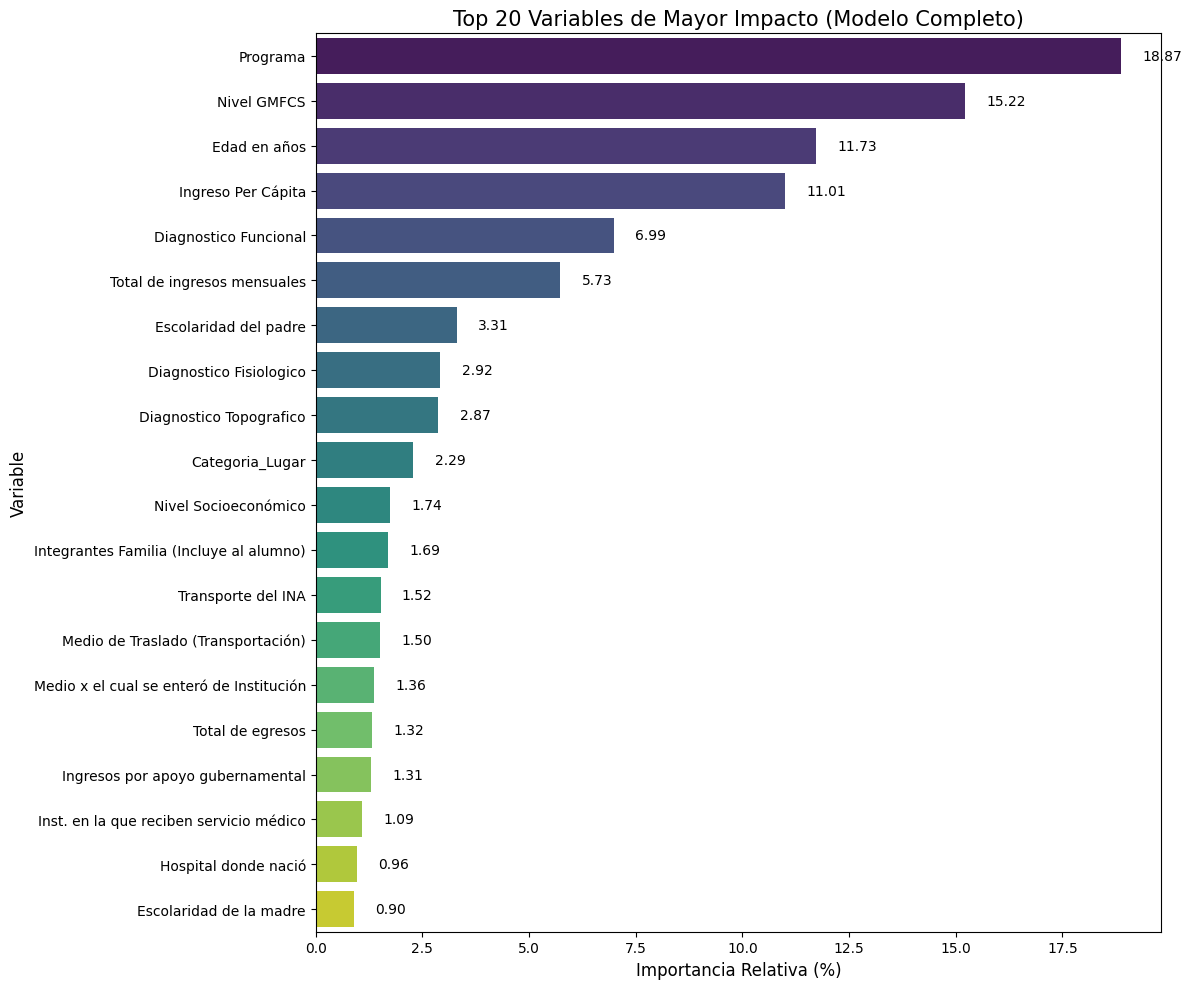


IMPORTANCIA DE VARIABLES - MODELO SIMPLIFICADO (TOP 15)


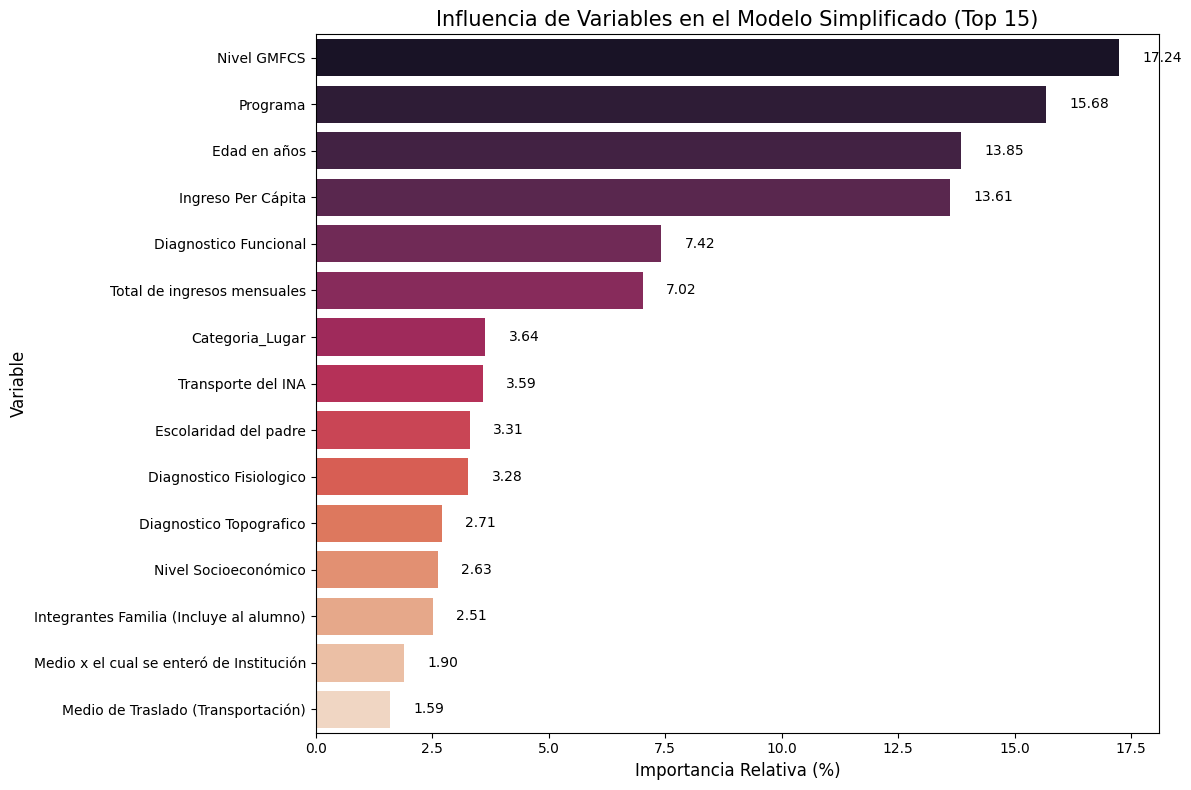

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. GRÁFICA: IMPORTANCIA DE VARIABLES - MODELO COMPLETO (FULL)
# ==============================================================================
print("\n" + "="*80)
print("TOP 20 VARIABLES MÁS IMPORTANTES - MODELO COMPLETO")
print("="*80)

# Tomamos las 20 mejores para que la gráfica sea legible
top_n_full = 20
df_plot_full = feat_imp_full.head(top_n_full)

plt.figure(figsize=(12, 10))
# Paleta de colores degradada (azules/verdes)
ax1 = sns.barplot(data=df_plot_full, x='Importance', y='Feature', palette='viridis')

plt.title(f'Top {top_n_full} Variables de Mayor Impacto (Modelo Completo)', fontsize=15)
plt.xlabel('Importancia Relativa (%)', fontsize=12)
plt.ylabel('Variable', fontsize=12)

# Agregar el valor numérico al final de cada barra
for i, p in enumerate(ax1.patches):
    width = p.get_width()
    ax1.text(width + 0.5, p.get_y() + p.get_height()/2, 
             f'{width:.2f}', ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


# ==============================================================================
# 2. GRÁFICA: IMPORTANCIA DE VARIABLES - MODELO SIMPLIFICADO (TOP 15)
# ==============================================================================
print("\n" + "="*80)
print("IMPORTANCIA DE VARIABLES - MODELO SIMPLIFICADO (TOP 15)")
print("="*80)

# Aquí mostramos todas las que tenga el modelo simplificado (usualmente 15)
plt.figure(figsize=(12, 8))
# Usamos otra paleta para diferenciar (ej. "magma" o "rocket")
ax2 = sns.barplot(data=feat_imp_top, x='Importance', y='Feature', palette='rocket')

plt.title('Influencia de Variables en el Modelo Simplificado (Top 15)', fontsize=15)
plt.xlabel('Importancia Relativa (%)', fontsize=12)
plt.ylabel('Variable', fontsize=12)

# Agregar el valor numérico
for i, p in enumerate(ax2.patches):
    width = p.get_width()
    ax2.text(width + 0.5, p.get_y() + p.get_height()/2, 
             f'{width:.2f}', ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

## Seccion  nueva
Febrero 2026

In [9]:
# ==============================================================================
# --- NUEVA SECCIÓN: ANÁLISIS COMPARATIVO TOP 15, TOP 10, TOP 5 ---
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_curve
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold

print("\n" + "="*80)
print("INICIANDO EVALUACIÓN DE MODELOS REDUCIDOS (TOP 15, 10, 5)")
print("="*80)

# 1. Extraer las listas de las mejores variables desde el modelo FULL
top_15_feat = feat_imp_full.head(15)['Feature'].tolist()
top_10_feat = feat_imp_full.head(10)['Feature'].tolist()
top_5_feat  = feat_imp_full.head(5)['Feature'].tolist()

# 2. Función dedicada para entrenar y evaluar cada subconjunto
def evaluar_subset(features_subset, nombre_modelo):
    print(f"\n--- Entrenando: {nombre_modelo} ({len(features_subset)} variables) ---")
    print(f"Variables usadas: {features_subset}")
    
    # Filtrar datos
    X_train_sub = X_train_full[features_subset].copy()
    X_test_sub  = X_test_full[features_subset].copy()
    
    # Identificar categóricas del subset
    cat_features_sub = X_train_sub.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Variables para guardar predicciones
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_random_seed)
    y_train_pred_proba_oof = np.zeros(len(y_train))
    y_test_pred_proba_total = np.zeros(len(y_test))
    
    # Ciclo K-Fold (Misma estructura de tu CatBoost actual)
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sub, y_train), 1):
        X_tr, X_val = X_train_sub.iloc[train_idx], X_train_sub.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        train_pool = Pool(X_tr, y_tr, cat_features=cat_features_sub)
        val_pool   = Pool(X_val, y_val, cat_features=cat_features_sub)
        
        model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.01,
            depth=6,
            l2_leaf_reg=10, 
            loss_function='Logloss',
            eval_metric='AUC',
            early_stopping_rounds=150,
            random_seed=global_random_seed,
            verbose=0,
            class_weights=class_weights,
            task_type=device_type,
            allow_writing_files=False
        )
        
        model.fit(train_pool, eval_set=val_pool, use_best_model=True, plot=False)
        
        y_train_pred_proba_oof[val_idx] = model.predict_proba(X_val)[:,1]
        y_test_pred_proba_total += model.predict_proba(X_test_sub)[:,1] / skf.n_splits
        
    # Calcular Umbral forzando Sensibilidad al 90% en OOF
    fpr, tpr, roc_thresholds = roc_curve(y_train, y_train_pred_proba_oof)
    idx_90 = np.argmax(tpr >= 0.90)
    thr_90 = roc_thresholds[idx_90]
    
    # Aplicar umbral para obtener 0s y 1s
    y_train_pred_bin = (y_train_pred_proba_oof >= thr_90).astype(int)
    y_test_pred_bin  = (y_test_pred_proba_total >= thr_90).astype(int)
    
    # Función auxiliar matemática para Especificidad (TN / (TN + FP))
    def calc_specificity(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else 0
        
    # Calcular Métricas Finales
    acc_train = accuracy_score(y_train, y_train_pred_bin)
    acc_test  = accuracy_score(y_test, y_test_pred_bin)
    
    sens_train = recall_score(y_train, y_train_pred_bin)
    sens_test  = recall_score(y_test, y_test_pred_bin)
    
    spec_train = calc_specificity(y_train, y_train_pred_bin)
    spec_test  = calc_specificity(y_test, y_test_pred_bin)
    
    # Empaquetar resultados
    resultados = {
        'Métrica': ['Sensibilidad (Recall)', 'Especificidad', 'Accuracy'],
        'Train OOF': [sens_train, spec_train, acc_train],
        'Test': [sens_test, spec_test, acc_test]
    }
    
    df_res = pd.DataFrame(resultados).set_index('Métrica')
    print(f"-> Umbral calculado (Sens 95%): {thr_90:.4f}")
    print(df_res.round(4))
    
    return df_res

# 3. Ejecutar los 3 modelos
res_top15 = evaluar_subset(top_15_feat, "MODELO TOP 15")
res_top10 = evaluar_subset(top_10_feat, "MODELO TOP 10")
res_top5  = evaluar_subset(top_5_feat,  "MODELO TOP 5")

# 4. Generar Tabla Resumen Comparativa Final
print("\n" + "="*80)
print("RESUMEN COMPARATIVO FINAL: TOP 15 vs TOP 10 vs TOP 5")
print("="*80)

df_comparativo = pd.DataFrame({
    'Métrica': [
        'Sensibilidad (Train OOF)', 'Sensibilidad (Test)', 
        'Especificidad (Train OOF)', 'Especificidad (Test)', 
        'Accuracy (Train OOF)', 'Accuracy (Test)'
    ],
    'TOP 15': [
        res_top15.loc['Sensibilidad (Recall)', 'Train OOF'], res_top15.loc['Sensibilidad (Recall)', 'Test'], 
        res_top15.loc['Especificidad', 'Train OOF'], res_top15.loc['Especificidad', 'Test'],
        res_top15.loc['Accuracy', 'Train OOF'], res_top15.loc['Accuracy', 'Test']
    ],
    'TOP 10': [
        res_top10.loc['Sensibilidad (Recall)', 'Train OOF'], res_top10.loc['Sensibilidad (Recall)', 'Test'], 
        res_top10.loc['Especificidad', 'Train OOF'], res_top10.loc['Especificidad', 'Test'],
        res_top10.loc['Accuracy', 'Train OOF'], res_top10.loc['Accuracy', 'Test']
    ],
    'TOP 5':  [
        res_top5.loc['Sensibilidad (Recall)', 'Train OOF'], res_top5.loc['Sensibilidad (Recall)', 'Test'], 
        res_top5.loc['Especificidad', 'Train OOF'], res_top5.loc['Especificidad', 'Test'],
        res_top5.loc['Accuracy', 'Train OOF'], res_top5.loc['Accuracy', 'Test']
    ]
}).set_index('Métrica')

print(df_comparativo.round(4))


INICIANDO EVALUACIÓN DE MODELOS REDUCIDOS (TOP 15, 10, 5)

--- Entrenando: MODELO TOP 15 (15 variables) ---
Variables usadas: ['Programa', 'Nivel GMFCS', 'Edad en años', 'Ingreso Per Cápita', 'Diagnostico Funcional', 'Total de ingresos mensuales', 'Escolaridad del padre', 'Diagnostico Fisiologico', 'Diagnostico Topografico', 'Categoria_Lugar', 'Nivel Socioeconómico', 'Integrantes Familia (Incluye al alumno)', 'Transporte del INA', 'Medio de Traslado (Transportación)', 'Medio x el cual se enteró de Institución']


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


-> Umbral calculado (Sens 95%): 0.5558
                       Train OOF    Test
Métrica                                 
Sensibilidad (Recall)     0.9026  0.8875
Especificidad             0.4025  0.4533
Accuracy                  0.7306  0.7489

--- Entrenando: MODELO TOP 10 (10 variables) ---
Variables usadas: ['Programa', 'Nivel GMFCS', 'Edad en años', 'Ingreso Per Cápita', 'Diagnostico Funcional', 'Total de ingresos mensuales', 'Escolaridad del padre', 'Diagnostico Fisiologico', 'Diagnostico Topografico', 'Categoria_Lugar']


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


-> Umbral calculado (Sens 95%): 0.5413
                       Train OOF    Test
Métrica                                 
Sensibilidad (Recall)     0.9010  0.8875
Especificidad             0.3901  0.4267
Accuracy                  0.7252  0.7404

--- Entrenando: MODELO TOP 5 (5 variables) ---
Variables usadas: ['Programa', 'Nivel GMFCS', 'Edad en años', 'Ingreso Per Cápita', 'Diagnostico Funcional']


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


-> Umbral calculado (Sens 95%): 0.5065
                       Train OOF    Test
Métrica                                 
Sensibilidad (Recall)     0.9026  0.8750
Especificidad             0.3622  0.4000
Accuracy                  0.7167  0.7234

RESUMEN COMPARATIVO FINAL: TOP 15 vs TOP 10 vs TOP 5
                           TOP 15  TOP 10   TOP 5
Métrica                                          
Sensibilidad (Train OOF)   0.9026  0.9010  0.9026
Sensibilidad (Test)        0.8875  0.8875  0.8750
Especificidad (Train OOF)  0.4025  0.3901  0.3622
Especificidad (Test)       0.4533  0.4267  0.4000
Accuracy (Train OOF)       0.7306  0.7252  0.7167
Accuracy (Test)            0.7489  0.7404  0.7234


In [ ]:
# ==============================================================================
# --- NUEVA SECCIÓN: ANÁLISIS COMPARATIVO ESTÁNDAR (SIN FORZAR SENSIBILIDAD) ---
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold

print("\n" + "="*80)
print("INICIANDO EVALUACIÓN DE MODELOS REDUCIDOS (TOP 15, 10, 5) - UMBRAL ESTÁNDAR (0.5)")
print("="*80)

# 1. Extraer las listas de las mejores variables desde el modelo FULL
top_15_feat = feat_imp_full.head(15)['Feature'].tolist()
top_10_feat = feat_imp_full.head(10)['Feature'].tolist()
top_5_feat  = feat_imp_full.head(5)['Feature'].tolist()

# 2. Función dedicada para entrenar y evaluar cada subconjunto de forma natural
def evaluar_subset_estandar(features_subset, nombre_modelo):
    print(f"\n--- Entrenando: {nombre_modelo} ({len(features_subset)} variables) ---")
    
    # Filtrar datos
    X_train_sub = X_train_full[features_subset].copy()
    X_test_sub  = X_test_full[features_subset].copy()
    
    # Identificar categóricas del subset
    cat_features_sub = X_train_sub.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Variables para guardar predicciones
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_random_seed)
    y_train_pred_proba_oof = np.zeros(len(y_train))
    y_test_pred_proba_total = np.zeros(len(y_test))
    
    # Ciclo K-Fold 
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sub, y_train), 1):
        X_tr, X_val = X_train_sub.iloc[train_idx], X_train_sub.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        train_pool = Pool(X_tr, y_tr, cat_features=cat_features_sub)
        val_pool   = Pool(X_val, y_val, cat_features=cat_features_sub)
        
        model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.01,
            depth=6,
            l2_leaf_reg=10, 
            loss_function='Logloss',
            eval_metric='AUC',
            early_stopping_rounds=150,
            random_seed=global_random_seed,
            verbose=0,
            class_weights=class_weights, # Mantiene el balanceo natural de clases
            task_type=device_type,
            allow_writing_files=False
        )
        
        model.fit(train_pool, eval_set=val_pool, use_best_model=True, plot=False)
        
        y_train_pred_proba_oof[val_idx] = model.predict_proba(X_val)[:,1]
        y_test_pred_proba_total += model.predict_proba(X_test_sub)[:,1] / skf.n_splits
        
    # UMBRAL ESTÁNDAR NATURAL (0.5) - Sin forzar métricas
    thr_std = 0.5
    y_train_pred_bin = (y_train_pred_proba_oof >= thr_std).astype(int)
    y_test_pred_bin  = (y_test_pred_proba_total >= thr_std).astype(int)
    
    # Función auxiliar matemática para Especificidad (TN / (TN + FP))
    def calc_specificity(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else 0
        
    # Calcular Métricas Finales Naturales
    acc_train = accuracy_score(y_train, y_train_pred_bin)
    acc_test  = accuracy_score(y_test, y_test_pred_bin)
    
    sens_train = recall_score(y_train, y_train_pred_bin)
    sens_test  = recall_score(y_test, y_test_pred_bin)
    
    spec_train = calc_specificity(y_train, y_train_pred_bin)
    spec_test  = calc_specificity(y_test, y_test_pred_bin)
    
    # Empaquetar resultados
    resultados = {
        'Métrica': ['Sensibilidad (Recall)', 'Especificidad', 'Accuracy'],
        'Train OOF': [sens_train, spec_train, acc_train],
        'Test': [sens_test, spec_test, acc_test]
    }
    
    df_res = pd.DataFrame(resultados).set_index('Métrica')
    print(f"-> Umbral utilizado: {thr_std} (Estándar)")
    print(df_res.round(4))
    
    return df_res

# 3. Ejecutar los 3 modelos
res_top15 = evaluar_subset_estandar(top_15_feat, "MODELO TOP 15")
res_top10 = evaluar_subset_estandar(top_10_feat, "MODELO TOP 10")
res_top5  = evaluar_subset_estandar(top_5_feat,  "MODELO TOP 5")

# 4. Generar Tabla Resumen Comparativa Final
print("\n" + "="*80)
print("RESUMEN COMPARATIVO FINAL NATURAL (UMBRAL 0.5): TOP 15 vs TOP 10 vs TOP 5")
print("="*80)

df_comparativo = pd.DataFrame({
    'Métrica': [
        'Sensibilidad (Train OOF)', 'Sensibilidad (Test)', 
        'Especificidad (Train OOF)', 'Especificidad (Test)', 
        'Accuracy (Train OOF)', 'Accuracy (Test)'
    ],
    'TOP 15': [
        res_top15.loc['Sensibilidad (Recall)', 'Train OOF'], res_top15.loc['Sensibilidad (Recall)', 'Test'], 
        res_top15.loc['Especificidad', 'Train OOF'], res_top15.loc['Especificidad', 'Test'],
        res_top15.loc['Accuracy', 'Train OOF'], res_top15.loc['Accuracy', 'Test']
    ],
    'TOP 10': [
        res_top10.loc['Sensibilidad (Recall)', 'Train OOF'], res_top10.loc['Sensibilidad (Recall)', 'Test'], 
        res_top10.loc['Especificidad', 'Train OOF'], res_top10.loc['Especificidad', 'Test'],
        res_top10.loc['Accuracy', 'Train OOF'], res_top10.loc['Accuracy', 'Test']
    ],
    'TOP 5':  [
        res_top5.loc['Sensibilidad (Recall)', 'Train OOF'], res_top5.loc['Sensibilidad (Recall)', 'Test'], 
        res_top5.loc['Especificidad', 'Train OOF'], res_top5.loc['Especificidad', 'Test'],
        res_top5.loc['Accuracy', 'Train OOF'], res_top5.loc['Accuracy', 'Test']
    ]
}).set_index('Métrica')

print(df_comparativo.round(4))


INICIANDO EVALUACIÓN DE MODELOS REDUCIDOS (TOP 15, 10, 5) - UMBRAL ESTÁNDAR (0.5)

--- Entrenando: MODELO TOP 15 (15 variables) ---


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


-> Umbral utilizado: 0.5 (Estándar)
                       Train OOF    Test
Métrica                                 
Sensibilidad (Recall)     0.9188  0.8750
Especificidad             0.3406  0.4000
Accuracy                  0.7199  0.7234

--- Entrenando: MODELO TOP 10 (10 variables) ---


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


-> Umbral utilizado: 0.5 (Estándar)
                       Train OOF    Test
Métrica                                 
Sensibilidad (Recall)     0.9172  0.9062
Especificidad             0.3560  0.3600
Accuracy                  0.7242  0.7319

--- Entrenando: MODELO TOP 5 (5 variables) ---


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


-> Umbral utilizado: 0.5 (Estándar)
                       Train OOF    Test
Métrica                                 
Sensibilidad (Recall)     0.9205  0.8875
Especificidad             0.2941  0.3067
Accuracy                  0.7050  0.7021

RESUMEN COMPARATIVO FINAL NATURAL (UMBRAL 0.5): TOP 15 vs TOP 10 vs TOP 5
                           TOP 15  TOP 10   TOP 5
Métrica                                          
Sensibilidad (Train OOF)   0.9188  0.9172  0.9205
Sensibilidad (Test)        0.8750  0.9062  0.8875
Especificidad (Train OOF)  0.3406  0.3560  0.2941
Especificidad (Test)       0.4000  0.3600  0.3067
Accuracy (Train OOF)       0.7199  0.7242  0.7050
Accuracy (Test)            0.7234  0.7319  0.7021


Esta grafica esta haciendo el umbral para el semafor de que de 0 a 4 de esta manera, de 4 a 7 amarillo y de 7 a 10 rojo, no lo hace como el original semaforo 

usando la curva ROC para el 95% y el F1-Score máximo ahora esta otra

## Cambios de 10 de marzo

In [11]:
# ==============================================================================
# --- EJECUCIÓN FINAL: GENERACIÓN DE ARCHIVOS Y SEMÁFORO (AJUSTADO AL 90%) ---
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve
import os
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score

print("\n" + "="*80)
print("GENERANDO EXPORTACIÓN FINAL Y GRÁFICAS - MODELO RANGD")
print("="*80)

model_prefix = "FINAL"
features_final = top_10_feat

X_train_final = X_train_full[features_final].copy()
X_test_final  = X_test_full[features_final].copy()
cat_features_final = X_train_final.select_dtypes(include=['object', 'category']).columns.tolist()

# Variables para K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_random_seed)
y_train_pred_proba_oof = np.zeros(len(y_train))
y_test_pred_proba_total = np.zeros(len(y_test))
models_final = []

model_run_dir = f"{output_dir}/{model_prefix}_models"
os.makedirs(model_run_dir, exist_ok=True)

print(f"Entrenando K-Fold para el modelo definitivo ({len(features_final)} variables)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_final, y_train), 1):

    X_tr, X_val = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    train_pool = Pool(X_tr, y_tr, cat_features=cat_features_final)
    val_pool   = Pool(X_val, y_val, cat_features=cat_features_final)
    
    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.01,
        depth=6,
        l2_leaf_reg=10,
        loss_function='Logloss',
        eval_metric='AUC',
        early_stopping_rounds=150,
        random_seed=global_random_seed,
        verbose=0,
        class_weights=class_weights,
        task_type=device_type,
        allow_writing_files=False
    )
    
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, plot=False)
    
    y_train_pred_proba_oof[val_idx] = model.predict_proba(X_val)[:,1]
    y_test_pred_proba_total += model.predict_proba(X_test_final)[:,1] / skf.n_splits
    
    models_final.append(model)
    model.save_model(f"{model_run_dir}/fold_{fold}.cbm")

print("Entrenamiento finalizado. Calculando métricas y divisiones del semáforo...")

# --- CÁLCULO DE UMBRAL (Sensibilidad 90%) ---
fpr, tpr, roc_thresholds = roc_curve(y_train, y_train_pred_proba_oof)
idx_90 = np.argmax(tpr >= 0.90)  # Buscamos capturar al 90% de los positivos (Bajas)
thr_sensitivity_90 = roc_thresholds[idx_90]

# --- RANGOS FIJOS DEL SEMÁFORO ---
final_thr_low = 0.35
final_thr_high = 0.70

# --- MÉTRICAS CON UMBRAL DE SENSIBILIDAD ---
# AQUI ESTÁ EL CAMBIO CLAVE: Ya no usamos el F1 Óptimo.
# Todo el modelo usará el umbral del 90% de sensibilidad para decir si es baja o no (1 o 0)
y_train_pred_bin = (y_train_pred_proba_oof >= thr_sensitivity_90).astype(int)
y_test_pred_bin  = (y_test_pred_proba_total >= thr_sensitivity_90).astype(int)

def calc_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

metrics = {
    'Accuracy': [accuracy_score(y_train, y_train_pred_bin), accuracy_score(y_test, y_test_pred_bin)],
    'Sensibilidad': [recall_score(y_train, y_train_pred_bin), recall_score(y_test, y_test_pred_bin)],
    'Especificidad': [calc_specificity(y_train, y_train_pred_bin), calc_specificity(y_test, y_test_pred_bin)]
}

metrics_df = pd.DataFrame(metrics, index=['Train OOF', 'Test']).T
metrics_df.to_csv(f"{output_dir}/{model_prefix}_02_metricas.csv")

# --- BARPLOT MÉTRICAS ---
ax = metrics_df.plot(kind='bar', figsize=(10,6), rot=0,
                     title=f'Métricas Finales ({model_prefix} - Decisión Sensibilidad 90%: {thr_sensitivity_90:.3f})')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{output_dir}/{model_prefix}_03_metricas_barplot.png")
plt.close()

# --- CURVA ROC ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Train OOF AUC={roc_auc_score(y_train, y_train_pred_proba_oof):.3f}')
fpr_te, tpr_te, _ = roc_curve(y_test, y_test_pred_proba_total)
plt.plot(fpr_te, tpr_te, label=f'Test AUC={roc_auc_score(y_test, y_test_pred_proba_total):.3f}')
plt.plot([0,1],[0,1],'r--')
plt.title(f'Curva ROC ({model_prefix})')
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}/{model_prefix}_04_curva_roc.png")
plt.close()

# --- DISTRIBUCIÓN Y SEMÁFORO ---
plt.figure(figsize=(10,6))
sns.histplot(y_train_pred_proba_oof[y_train==0], color='skyblue',
             label='Clase 0 (No Baja)', kde=True, stat="density", alpha=0.3)

sns.histplot(y_train_pred_proba_oof[y_train==1], color='salmon',
             label='Clase 1 (Baja)', kde=True, stat="density", alpha=0.3)

plt.axvspan(0, final_thr_low, color='green', alpha=0.1, label='Verde: Riesgo Bajo (0 - 0.35)')
plt.axvspan(final_thr_low, final_thr_high, color='yellow', alpha=0.1, label='Amarillo: Alerta (0.35 - 0.70)')
plt.axvspan(final_thr_high, 1.0, color='red', alpha=0.1, label='Rojo: Alto Riesgo (0.70 - 1.0)')

# También se corrigió aquí la línea vertical
plt.axvline(x=thr_sensitivity_90, color='black', linestyle='--',
            label=f'Umbral Decisión 90% Sensibilidad ({thr_sensitivity_90:.3f})')

plt.title(f'Distribución de Probabilidades y Semáforo ({model_prefix})')
plt.legend()
plt.savefig(f"{output_dir}/{model_prefix}_05_distribucion_semaforo.png")
plt.close()

# --- FEATURE IMPORTANCE ---
feat_imp_avg = pd.DataFrame({
    'Feature': features_final,
    'Importance': np.mean([m.get_feature_importance() for m in models_final], axis=0)
}).sort_values(by='Importance', ascending=False)

feat_imp_avg.to_csv(f"{output_dir}/{model_prefix}_07_feature_importance.csv", index=False)

# --- MATRIZ DE CONFUSIÓN (GENERAL Y POR SEMÁFORO) ---
y_test_arr = np.array(y_test)

def graficar_matriz(y_t, y_p, titulo, archivo):
    if len(y_t) == 0:
        return
    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Baja', 'Baja'])
    disp.plot(cmap='Blues')
    plt.title(titulo)
    plt.savefig(f"{output_dir}/{archivo}")
    plt.close()

# 1. Matriz General
graficar_matriz(y_test_arr, y_test_pred_bin, 
                f'Matriz Confusión General ({model_prefix})', 
                f'{model_prefix}_09_matriz_general.png')

# Filtros para cada zona del semáforo
idx_verde = y_test_pred_proba_total < final_thr_low
idx_amarillo = (y_test_pred_proba_total >= final_thr_low) & (y_test_pred_proba_total < final_thr_high)
idx_rojo = y_test_pred_proba_total >= final_thr_high

# 2. Matriz Zona Verde
graficar_matriz(y_test_arr[idx_verde], y_test_pred_bin[idx_verde], 
                f'Matriz Confusión - Zona Verde (<0.35)', 
                f'{model_prefix}_09a_matriz_verde.png')

# 3. Matriz Zona Amarilla
graficar_matriz(y_test_arr[idx_amarillo], y_test_pred_bin[idx_amarillo], 
                f'Matriz Confusión - Zona Amarilla (0.35-0.70)', 
                f'{model_prefix}_09b_matriz_amarilla.png')

# 4. Matriz Zona Roja
graficar_matriz(y_test_arr[idx_rojo], y_test_pred_bin[idx_rojo], 
                f'Matriz Confusión - Zona Roja (>=0.70)', 
                f'{model_prefix}_09c_matriz_roja.png')

# --- EXPORTACIÓN CSV FINAL ---
df_final_export = pd.DataFrame()
df_final_export['Matrícula'] = test_ids
df_final_export['Baja General_Real'] = y_test_arr
df_final_export['Probabilidad_Baja'] = y_test_pred_proba_total

def asignar_riesgo_final(prob):
    if prob >= final_thr_high:
        return 'Rojo (Alto Riesgo)'
    elif prob >= final_thr_low:
        return 'Amarillo (Alerta)'
    else:
        return 'Verde (Bajo Riesgo)'

df_final_export['Nivel_Riesgo'] = df_final_export['Probabilidad_Baja'].apply(asignar_riesgo_final)
df_final_export['Prediccion_Binaria_Dinamica'] = y_test_pred_bin

for col in features_final:
    df_final_export[col] = X_test_final[col].values

output_path = f"{output_dir}/RESULTADOS_SEMAFORO_RANGD.csv"
df_final_export.to_csv(output_path, index=False)

# --- IMPRESIÓN DE RESULTADOS AL FINAL ---
print("\n" + "="*80)
print("¡PROCESO COMPLETADO CON ÉXITO!")
print(f"Archivo generado: {output_path}")
print("-" * 80)
print(f"Cortes del Semáforo: Verde [0.00 - 0.34] | Amarillo [0.35 - 0.69] | Rojo [0.70 - 1.00]")
print(f"Umbral de Decisión Aplicado (Sensibilidad 90%): {thr_sensitivity_90:.4f}")
print("-" * 80)
print("MÉTRICAS GLOBALES DEL MODELO (CONJUNTO DE PRUEBA):")
print(f" -> Exactitud (Accuracy):  {metrics['Accuracy'][1]:.4f}")
print(f" -> Sensibilidad (Recall): {metrics['Sensibilidad'][1]:.4f}")
print(f" -> Especificidad:         {metrics['Especificidad'][1]:.4f}")
print("="*80)


GENERANDO EXPORTACIÓN FINAL Y GRÁFICAS - MODELO RANGD
Entrenando K-Fold para el modelo definitivo (10 variables)...


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


Entrenamiento finalizado. Calculando métricas y divisiones del semáforo...

¡PROCESO COMPLETADO CON ÉXITO!
Archivo generado: run_2026-03-10_18-05-33_HighSensitivity/RESULTADOS_SEMAFORO_RANGD.csv
--------------------------------------------------------------------------------
Cortes del Semáforo: Verde [0.00 - 0.34] | Amarillo [0.35 - 0.69] | Rojo [0.70 - 1.00]
Umbral de Decisión Aplicado (Sensibilidad 90%): 0.5339
--------------------------------------------------------------------------------
MÉTRICAS GLOBALES DEL MODELO (CONJUNTO DE PRUEBA):
 -> Exactitud (Accuracy):  0.7362
 -> Sensibilidad (Recall): 0.8875
 -> Especificidad:         0.4133
